## **Messwerte**

In [6]:
import numpy as np #Messwerte zu 3.1
import pandas as pd

t_Fehler = 0.1 #Fehler für die Messdaten der Zeit [rad]

alpha_Fehler = 0.1 #Fehler für die Messdaten der Ausnelkungswinkel V

x_Fehler = 0.2 #Fehler für das Ablesen der benachbarten Amplituden V

deltaT_Fehler = 0.2 #Fehler für das Ablesen des zeitlichen Abstands der Amplituden [s]

"""-----------------------------------------------------------------------------------------"""

df = pd.read_csv('TEK00000.CSV', skiprows=15)
df1 = pd.read_csv("TEK00002.CSV", skiprows=15)
df2 = pd.read_csv("TEK00003.CSV", skiprows=15)
df3 = pd.read_csv("TEK00004.CSV", skiprows=15)

#Verlauf der freien gedämpften Schwingung
t_0 = df["TIME"].to_numpy() #Zeit in Sekunden
#alpha_0 = np.array([37.6, 36.8, 36.8, 36.0, 35.2, 35.2, 35.2, 34.4, 34.4]) #Auslenkungswinkel in Radians
alpha_0 = df["CH2"].to_numpy()


x_0_a = 37.6 #zwei benachbarte Amplituden
x_0_b = 36.8
deltaT_0 = 1.92 #zeitlicher abstand der benachbarten Amplituden in s

"""-----------------------------------------------------------------------------------------"""

#Verlauf der gedämpften Schwingung mit I = 0.075A
t_1 = df1["TIME"] #Zeit in Sekunden
alpha_1 = df1["CH2"] #Auslenkungswinkel in Radians

x_1_a = 37.0 #zwei benachbarte Amplituden (gleiche Richtung d.h eine ganze Periode)
x_1_b = 35.4
deltaT_1 = 1.92 #zeitlicher abstand der benachbarten Amplituden in s

"""-----------------------------------------------------------------------------------------"""

#Verlauf der gedämpften Schwingung mit I = 0.150 A
t_2 = df2["TIME"] #Zeit in Sekunden
alpha_2 = df2["CH2"] #Auslenkungswinkel in Radians

x_2_a = 37.0 #zwei benachbarte Amplituden
x_2_b = 33.8
deltaT_2 = 1.96 #zeitlicher abstand der benachbarten Amplituden in s

"""-----------------------------------------------------------------------------------------"""

#Verlauf der gedämpften Schwingung mit I = 0.3000 A
t_3 = df3["TIME"] #Zeit in Sekunden
alpha_3 = df3["CH2"] #Auslenkungswinkel in Radians

x_3_a = 34.6 #zwei benachbarte Amplituden
x_3_b = 25.8
deltaT_3 = 1.96 #zeitlicher abstand der benachbarten Amplituden in s

## **Freie Schwingung**

lambda aus Fit: lambda = 0.007347232615264853 +/- 5.852455777310755e-05



log(x_0a/x_0b)

Logarithmisches Dekrement: A = 0.021506205220963682 +/- 0.007604617505761972



A/T

lmbda aus Dekrement: lmbda = 0.011201148552585251 +/- 0.004129023860895396



2*pi/T

sqrt(lambda**2 + omega_D**2)

Eigenfrequenz aus Dämpfung-Fit: omega_Eig = 3.27250059529461 +/- 0.3408837603859538 1/s
Eigenfrequenz aus Dämpfung-Dekrement: omega_Eig = 3.272511517184527 +/- 0.3408826229915636 1/s


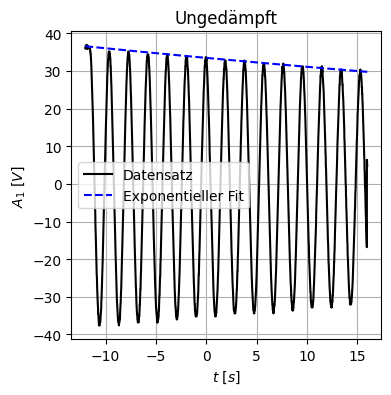

In [7]:
import scipy
import matplotlib.pyplot as plt
import sympy
from IPython.display import display
from Skripte.Fehlerfortpflanzung import Gaußfehler

"""
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'arial',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
"""

def f(x, lmbda, A): #Fit Funktion
    return A*np.exp(-lmbda*x)

peaks_0 = scipy.signal.find_peaks(alpha_0, height=28)[0][8:] #get the indices of the peaks


coefficients, pcov = scipy.optimize.curve_fit(f, t_0[peaks_0], alpha_0[peaks_0], sigma= alpha_Fehler, absolute_sigma= True)

lmbda_0 = coefficients[0]
lmbda_0_Fehler = np.sqrt(pcov[0,0])

A_0 = coefficients[1]
A_0_Fehler = np.sqrt(pcov[1,1])

print(f"lambda aus Fit: lambda = {lmbda_0} +/- {lmbda_0_Fehler}\n")

"""-----------------------------------------------------------------------------------------"""
#Plot

fig, ax0 = plt.subplots(1,1, figsize = (4,4))

ax0.plot(t_0[250:], alpha_0[250:], label = "Datensatz", color = "black")
ax0.plot(t_0[250:], f(t_0, lmbda_0, A_0)[250:], color = "blue", linestyle = "--", label = "Exponentieller Fit")

ax0.set_xlabel("$t~[s]$")
ax0.set_ylabel("$A_1~[V]$")
ax0.grid(True)
ax0.set_title("Ungedämpft")
ax0.legend()

"""-----------------------------------------------------------------------------------------"""
logDek_0 = np.log(x_0_a/x_0_b) #logarithmisches Dekrement

x0a, x0b = sympy.symbols("x_0a, x_0b")
expr1 = sympy.log(x0a/x0b)
display(expr1)

logDek_0_Fehler = Gaußfehler(expr1, np.array([x0a, x0b]), np.array([x_0_a, x_0_b]), np.array([x_Fehler, x_Fehler]))

print(f"Logarithmisches Dekrement: A = {logDek_0} +/- {logDek_0_Fehler}\n")

lmbda_0_log = logDek_0/deltaT_0 #Dämpfungskonsante aus log Dek

Ap, Tp = sympy.symbols("A, T")
expr2 = Ap/Tp
display(expr2)

lmbda_0_log_Fehler = Gaußfehler(expr2, np.array([Ap, Tp]), np.array([logDek_0, deltaT_0]), np.array([logDek_0_Fehler, deltaT_Fehler]))

print(f"lmbda aus Dekrement: lmbda = {lmbda_0_log} +/- {lmbda_0_log_Fehler}\n")

"""-----------------------------------------------------------------------------------------"""
#Eigenfrequenzen

omega_0 = 2*np.pi / deltaT_0 #Beobachtete Frequenz der Schwingung
expr3 = 2*sympy.pi / Tp
display(expr3)
omega_0_Fehler = Gaußfehler(expr3, np.array([Tp]), np.array([deltaT_0]), np.array([deltaT_Fehler]))

print("\n")

omegaEig_0_fit = np.sqrt(omega_0**2 + lmbda_0**2) #Eigenfrequenz mit dem lambda aus dem Fit
omegaEig_0_log = np.sqrt(omega_0**2 + lmbda_0_log**2) #Eigenfrequenz mit dem lambda aus dem logatithmischen Dekrement

lb, op = sympy.symbols("lambda, omega_D")
expr4 = sympy.sqrt(lb**2 + op**2)
display(expr4)

omegaEig_0_fit_Fehler = Gaußfehler(expr4, np.array([lb, op]), np.array([lmbda_0, omega_0]), np.array([lmbda_0_Fehler, omega_0_Fehler]))
omegaEig_0_log_Fehler = Gaußfehler(expr4, np.array([lb, op]), np.array([lmbda_0_log, omega_0]), np.array([lmbda_0_log_Fehler, omega_0_Fehler]))

print(f"Eigenfrequenz aus Dämpfung-Fit: omega_Eig = {omegaEig_0_fit} +/- {omegaEig_0_fit_Fehler} 1/s")
print(f"Eigenfrequenz aus Dämpfung-Dekrement: omega_Eig = {omegaEig_0_log} +/- {omegaEig_0_log_Fehler} 1/s")

#plt.savefig("Dämpfung_0.pgf")

## **Dämpfung 1**

lambda aus Fit: lambda = 0.0181088335080492 +/- 8.183017184414762e-05



log(x_1a/x_1b)

Logarithmisches Dekrement: A = 0.044206092504495705 +/- 0.007819061042490253



A/T

lmbda aus Dekrement: lmbda = 0.02302400651275818 +/- 0.004726168935123144



2*pi/T

sqrt(lambda**2 + omega_D**2)

Eigenfrequenz aus Dämpfung-Fit: omega_Eig = 3.272542451096318 +/- 0.34087940048462567 1/s
Eigenfrequenz aus Dämpfung-Dekrement: omega_Eig = 3.2725733405459954 +/- 0.34087618458392877 1/s


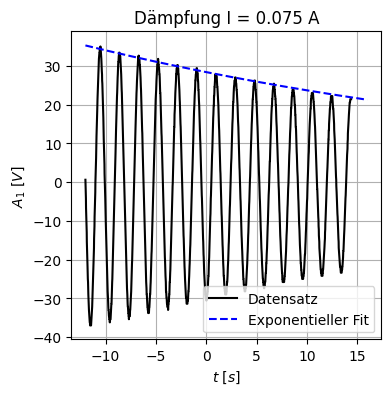

In [8]:
"""
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'arial',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
"""

def f(x, lmbda, A): #Fit Funktion
    return A*np.exp(-lmbda*x)

peaks_1 = scipy.signal.find_peaks(alpha_1, height = 20)[0][5:] #get the indices of the peaks

coefficients, pcov = scipy.optimize.curve_fit(f, t_1[peaks_1], alpha_1[peaks_1], sigma= alpha_Fehler, absolute_sigma= True)

lmbda_1 = coefficients[0]
lmbda_1_Fehler = np.sqrt(pcov[0,0])

A_1 = coefficients[1]
A_1_Fehler = np.sqrt(pcov[1,1])

print(f"lambda aus Fit: lambda = {lmbda_1} +/- {lmbda_1_Fehler}\n")

"""-----------------------------------------------------------------------------------------"""
#Plot

fig, ax1 = plt.subplots(1,1, figsize = (4,4))

ax1.plot(t_1[250:1900], alpha_1[250:1900], label = "Datensatz", color = "black")
ax1.plot(t_1[250:], f(t_1, lmbda_1, A_1)[250:], color = "blue", linestyle = "--", label = "Exponentieller Fit")

ax1.set_xlabel("$t~[s]$")
ax1.set_ylabel("$A_1~[V]$")
ax1.grid(True)
ax1.set_title("Dämpfung I = 0.075 A")
ax1.legend()

"""-----------------------------------------------------------------------------------------"""

logDek_1 = np.log(x_1_a/x_1_b) #logarithmisches Dekrement

x1a, x1b = sympy.symbols("x_1a, x_1b")
expr1 = sympy.log(x1a/x1b)
display(expr1)

logDek_1_Fehler = Gaußfehler(expr1, np.array([x1a, x1b]), np.array([x_1_a, x_1_b]), np.array([x_Fehler, x_Fehler]))

print(f"Logarithmisches Dekrement: A = {logDek_1} +/- {logDek_1_Fehler}\n")

lmbda_1_log = logDek_1/deltaT_1 #Dämpfungskonsante aus log Dek

Ap, Tp = sympy.symbols("A, T")
expr2 = Ap/Tp
display(expr2)

lmbda_1_log_Fehler = Gaußfehler(expr2, np.array([Ap, Tp]), np.array([logDek_1, deltaT_1]), np.array([logDek_1_Fehler, deltaT_Fehler]))

print(f"lmbda aus Dekrement: lmbda = {lmbda_1_log} +/- {lmbda_1_log_Fehler}\n")

"""-----------------------------------------------------------------------------------------"""
#Eigenfrequenzen

omega_1 = 2*np.pi / deltaT_1 #omega der Schwigung
expr3 = 2*sympy.pi / Tp
display(expr3)
omega_1_Fehler = Gaußfehler(expr3, np.array([Tp]), np.array([deltaT_1]), np.array([deltaT_Fehler]))

print("\n")

omegaEig_1_fit = np.sqrt(omega_1**2 + lmbda_1**2) #Eigenfrequent mit dem lambda aus dem Fit
omegaEig_1_log = np.sqrt(omega_1**2 + lmbda_1_log**2) #Eigenfrequenz mit dem lambda aus dem logatithmischen Dekrement

lb, op = sympy.symbols("lambda, omega_D")
expr4 = sympy.sqrt(lb**2 + op**2)
display(expr4)

omegaEig_1_fit_Fehler = Gaußfehler(expr4, np.array([lb, op]), np.array([lmbda_1, omega_1]), np.array([lmbda_1_Fehler, omega_1_Fehler]))
omegaEig_1_log_Fehler = Gaußfehler(expr4, np.array([lb, op]), np.array([lmbda_1_log, omega_1]), np.array([lmbda_1_log_Fehler, omega_1_Fehler]))

print(f"Eigenfrequenz aus Dämpfung-Fit: omega_Eig = {omegaEig_1_fit} +/- {omegaEig_1_fit_Fehler} 1/s")
print(f"Eigenfrequenz aus Dämpfung-Dekrement: omega_Eig = {omegaEig_1_log} +/- {omegaEig_1_log_Fehler} 1/s")

#plt.savefig("Dämpfung 1.pgf")

## **Dämpfung 2**

lambda aus Fit: lambda = 0.046203874048214674 +/- 0.00019712235776931714



log(x_2a/x_2b)

Logarithmisches Dekrement: A = 0.09045711015525139 +/- 0.008014436178631878



A/T

lmbda aus Dekrement: lmbda = 0.04615158681390377 +/- 0.006236813366796794



2*pi/T

sqrt(lambda**2 + omega_D**2)

Eigenfrequenz aus Dämpfung-Fit: omega_Eig = 3.2060397404644 +/- 0.3270789666314851 1/s
Eigenfrequenz aus Dämpfung-Dekrement: omega_Eig = 3.2060389873526827 +/- 0.32707905577326174 1/s


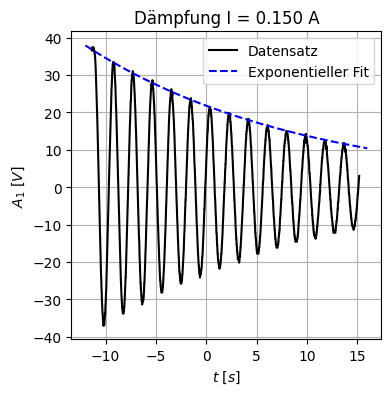

In [9]:

"""
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'arial',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
"""

def f(x, lmbda, A): #Fit Funktion
    return A*np.exp(-lmbda*x)

peaks_2 = scipy.signal.find_peaks(alpha_2, height = 20) #get the indices of the peaks

coefficients, pcov = scipy.optimize.curve_fit(f, t_2[peaks_2[0]], alpha_2[peaks_2[0]], sigma= alpha_Fehler, absolute_sigma= True)

lmbda_2 = coefficients[0]
lmbda_2_Fehler = np.sqrt(pcov[0,0])

A_2 = coefficients[1]
A_2_Fehler = np.sqrt(pcov[1,1])

print(f"lambda aus Fit: lambda = {lmbda_2} +/- {lmbda_2_Fehler}\n")

"""-----------------------------------------------------------------------------------------"""
#Plot

fig, ax2 = plt.subplots(1,1, figsize = (4,4))

ax2.plot(t_2[290:1950], alpha_2[290:1950], label = "Datensatz", color = "black")
ax2.plot(t_2[250:], f(t_2, lmbda_2, A_2)[250:], color = "blue", linestyle = "--", label = "Exponentieller Fit")

ax2.set_xlabel("$t~[s]$")
ax2.set_ylabel("$A_1~[V]$")
ax2.grid(True)
ax2.set_title("Dämpfung I = 0.150 A")
ax2.legend()

"""-----------------------------------------------------------------------------------------"""

logDek_2 = np.log(x_2_a/x_2_b) #logarithmisches Dekrement

x2a, x2b = sympy.symbols("x_2a, x_2b")
expr1 = sympy.log(x2a/x2b)
display(expr1)

logDek_2_Fehler = Gaußfehler(expr1, np.array([x2a, x2b]), np.array([x_2_a, x_2_b]), np.array([x_Fehler, x_Fehler]))

print(f"Logarithmisches Dekrement: A = {logDek_2} +/- {logDek_2_Fehler}\n")

lmbda_2_log = logDek_2/deltaT_2 #Dämpfungskonsante aus log Dek

Ap, Tp = sympy.symbols("A, T")
expr2 = Ap/Tp
display(expr2)

lmbda_2_log_Fehler = Gaußfehler(expr2, np.array([Ap, Tp]), np.array([logDek_2, deltaT_2]), np.array([logDek_2_Fehler, deltaT_Fehler]))

print(f"lmbda aus Dekrement: lmbda = {lmbda_2_log} +/- {lmbda_2_log_Fehler}\n")

"""-----------------------------------------------------------------------------------------"""
#Eigenfrequenzen

omega_2 = 2*np.pi / deltaT_2 #omega der Schwigung
expr3 = 2*sympy.pi / Tp
display(expr3)
omega_2_Fehler = Gaußfehler(expr3, np.array([Tp]), np.array([deltaT_2]), np.array([deltaT_Fehler]))

print("\n")

omegaEig_2_fit = np.sqrt(omega_2**2 + lmbda_2**2) #Eigenfrequent mit dem lambda aus dem Fit
omegaEig_2_log = np.sqrt(omega_2**2 + lmbda_2_log**2) #Eigenfrequenz mit dem lambda aus dem logatithmischen Dekrement

lb, op = sympy.symbols("lambda, omega_D")
expr4 = sympy.sqrt(lb**2 + op**2)
display(expr4)

omegaEig_2_fit_Fehler = Gaußfehler(expr4, np.array([lb, op]), np.array([lmbda_2, omega_2]), np.array([lmbda_2_Fehler, omega_2_Fehler]))
omegaEig_2_log_Fehler = Gaußfehler(expr4, np.array([lb, op]), np.array([lmbda_2_log, omega_2]), np.array([lmbda_2_log_Fehler, omega_2_Fehler]))

print(f"Eigenfrequenz aus Dämpfung-Fit: omega_Eig = {omegaEig_2_fit} +/- {omegaEig_2_fit_Fehler} 1/s")
print(f"Eigenfrequenz aus Dämpfung-Dekrement: omega_Eig = {omegaEig_2_log} +/- {omegaEig_2_log_Fehler} 1/s")
#plt.savefig("Dämpfung_2.pgf")

## **Dämpfung 3**

lambda aus Fit: lambda = 0.14309637167366732 +/- 0.000643736843827433



log(x_3a/x_3b)

Logarithmisches Dekrement: A = 0.2934791901361068 +/- 0.009669795855358758



A/T

lmbda aus Dekrement: lmbda = 0.14973428068168715 +/- 0.01605578396573566



2*pi/T

sqrt(lambda**2 + omega_D**2)

Eigenfrequenz aus Dämpfung-Fit: omega_Eig = 3.208898968656717 +/- 0.326787530408274 1/s
Eigenfrequenz aus Dämpfung-Dekrement: omega_Eig = 3.2092018282232164 +/- 0.32675754820567715 1/s


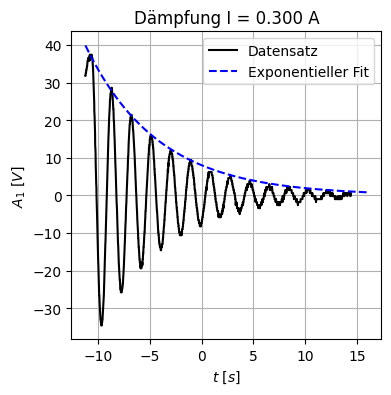

In [10]:

"""
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'arial',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
"""

def f(x, lmbda, A): #Fit Funktion
    return A*np.exp(-lmbda*x)

peaks_3 = scipy.signal.find_peaks(alpha_3, height = 10) #get the indices of the peaks

coefficients, pcov = scipy.optimize.curve_fit(f, t_3[peaks_3[0]], alpha_3[peaks_3[0]], sigma= alpha_Fehler, absolute_sigma= True)

lmbda_3 = coefficients[0]
lmbda_3_Fehler = np.sqrt(pcov[0,0])

A_3 = coefficients[1]
A_3_Fehler = np.sqrt(pcov[1,1])

print(f"lambda aus Fit: lambda = {lmbda_3} +/- {lmbda_3_Fehler}\n")

"""-----------------------------------------------------------------------------------------"""
#Plot

fig, ax3 = plt.subplots(1,1, figsize = (4,4))

ax3.plot(t_3[300:1900], alpha_3[300:1900], label = "Datensatz", color = "black")
ax3.plot(t_3[300:], f(t_3, lmbda_3, A_3)[300:], color = "blue", linestyle = "--", label = "Exponentieller Fit")

ax3.set_xlabel("$t~[s]$")
ax3.set_ylabel("$A_1~[V]$")
ax3.grid(True)
ax3.set_title("Dämpfung I = 0.300 A")
ax3.legend()

"""-----------------------------------------------------------------------------------------"""

logDek_3 = np.log(x_3_a/x_3_b) #logarithmisches Dekrement

x3a, x3b = sympy.symbols("x_3a, x_3b")
expr1 = sympy.log(x3a/x3b)
display(expr1)

logDek_3_Fehler = Gaußfehler(expr1, np.array([x3a, x3b]), np.array([x_3_a, x_3_b]), np.array([x_Fehler, x_Fehler]))

print(f"Logarithmisches Dekrement: A = {logDek_3} +/- {logDek_3_Fehler}\n")

lmbda_3_log = logDek_3/deltaT_3 #Dämpfungskonsante aus log Dek

Ap, Tp = sympy.symbols("A, T")
expr2 = Ap/Tp
display(expr2)

lmbda_3_log_Fehler = Gaußfehler(expr2, np.array([Ap, Tp]), np.array([logDek_3, deltaT_3]), np.array([logDek_3_Fehler, deltaT_Fehler]))

print(f"lmbda aus Dekrement: lmbda = {lmbda_3_log} +/- {lmbda_3_log_Fehler}\n")

"""-----------------------------------------------------------------------------------------"""
#Eigenfrequenzen

omega_3 = 2*np.pi / deltaT_3 #Beobachtete Frequenz der Schwingung
expr3 = 2*sympy.pi / Tp
display(expr3)
omega_3_Fehler = Gaußfehler(expr3, np.array([Tp]), np.array([deltaT_3]), np.array([deltaT_Fehler]))

print("\n")

omegaEig_3_fit = np.sqrt(omega_3**2 + lmbda_3**2) #Eigenfrequent mit dem lambda aus dem Fit
omegaEig_3_log = np.sqrt(omega_3**2 + lmbda_3_log**2) #Eigenfrequenz mit dem lambda aus dem logatithmischen Dekrement

lb, op = sympy.symbols("lambda, omega_D")
expr4 = sympy.sqrt(lb**2 + op**2)
display(expr4)

omegaEig_3_fit_Fehler = Gaußfehler(expr4, np.array([lb, op]), np.array([lmbda_3, omega_3]), np.array([lmbda_3_Fehler, omega_3_Fehler]))
omegaEig_3_log_Fehler = Gaußfehler(expr4, np.array([lb, op]), np.array([lmbda_3_log, omega_3]), np.array([lmbda_3_log_Fehler, omega_3_Fehler]))

print(f"Eigenfrequenz aus Dämpfung-Fit: omega_Eig = {omegaEig_3_fit} +/- {omegaEig_3_fit_Fehler} 1/s")
print(f"Eigenfrequenz aus Dämpfung-Dekrement: omega_Eig = {omegaEig_3_log} +/- {omegaEig_3_log_Fehler} 1/s")
#plt.savefig("Dämpfung_3.pgf")